In [1]:
#Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#grid
sns.set_theme(style="whitegrid")

#Modelling Libraries
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Fix the random seed so every random step below is reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Import data

df = pd.read_csv('loan-train.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


**Note:**
`Credit_History` Indicates if the applicant has a reliable past payment record.

* **`1`** $\rightarrow$ Good history (debts paid on time).
* **`0`** $\rightarrow$ Bad history (late payments or defaults).

# 1. Data Quality Checks
Lets validate the raw data first: missing values, duplicated rows, and impossible values...

In [3]:
# Count duplicate rows (identical across every column)
duplicate_rows_before = df.duplicated().sum()

# Check missing values per column. 
# markers like "?" or "N/A" are still stored as plain text and have not been converted yet.
missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print(f"Duplicate rows found: {duplicate_rows_before}")
print("\nColumns with missing values:")
display(missing_before.to_frame("missing_count"))

Duplicate rows found: 0

Columns with missing values:


,missing_count
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


In [4]:
# We clean missing values:

def prepare_frame(frame):
    data = frame.copy()
    data.columns = data.columns.astype(str).str.strip()
    data = data.replace({"?": np.nan, "_": np.nan, "": np.nan, "NA": np.nan, "N/A": np.nan})
    data = data.drop_duplicates().reset_index(drop=True)
    removable = [column for column in ["Loan_ID"] if column in data.columns]
    data = data.drop(columns=removable)
    return data.reset_index(drop=True)

data = prepare_frame(df)
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Note:**
- Replaces: `"?"`, `"_"`, `""`, `"NA"`, `"N/A"` with `np.nan` — these are just different spellings for
  "missing" used by the data source, but pandas only recognizes `np.nan` as real missing data. Without this,
  `.isna()` and the imputers later would miss them, and one-hot encoding would treat `"?"` as a real category.

    -NaNs are filled and handled later.

    -A blank cell in a CSV is not
  the same as the string `""`: `pd.read_csv()` already converts blank cells to real `np.nan` on load.

- Drops duplicate rows — repeated rows would bias the model toward those cases.
- Drops `Loan_ID` — it's just a row identifier, not a predictive feature.



In [5]:
# confirm what the cleaning step actually changed, by comparing before vs. after
rows_removed = df.shape[0] - data.shape[0]
missing_after = data.isna().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print(f"Rows before cleaning: {df.shape[0]:,} | Rows after cleaning: {data.shape[0]:,} "
      f"| Rows removed as duplicates: {rows_removed}")
print("\nColumns that still have missing values after cleaning (these are handled later, "
      "inside the preprocessing pipeline, not dropped here):")
display(missing_after.to_frame("missing_count"))

data.dtypes

Rows before cleaning: 614 | Rows after cleaning: 614 | Rows removed as duplicates: 0

Columns that still have missing values after cleaning (these are handled later, inside the preprocessing pipeline, not dropped here):


,missing_count
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

# 2. EDA

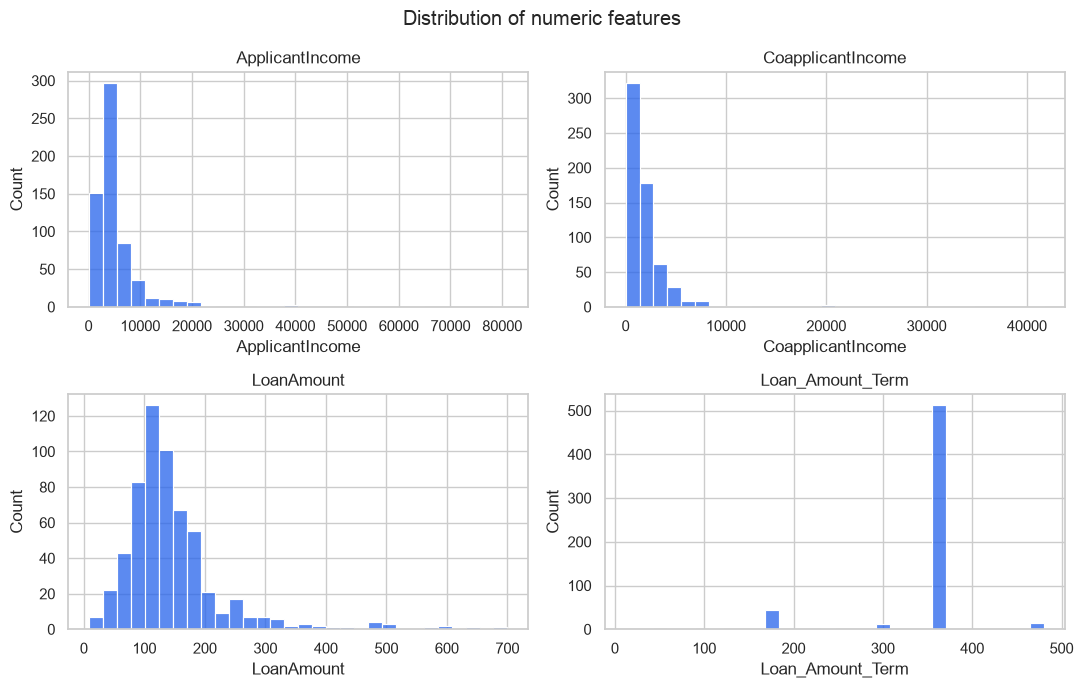

In [6]:
# We drop nans from the target!
eda_data = data.dropna(subset=["Loan_Status"]).copy() 

# Continuous numeric features to profile
# We exclude Credit_History since it behaves as categorical
numeric_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

# Plot a histogram for each numeric feature to see its shape (skew, outliers, typical range)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, column in zip(axes.ravel(), numeric_features):
    sns.histplot(eda_data[column].dropna(), bins=30, color="#2563eb", ax=ax)
    ax.set_title(column)
plt.suptitle("Distribution of numeric features")
plt.tight_layout()
plt.show()


**Interpretation:** `ApplicantIncome`, `CoapplicantIncome` and `LoanAmount` are all right-skewed, not
normally distributed (most values cluster low, with a long tail of a few high outliers pulling the mean above the median). `Loan_Amount_Term` is dominated by a single value (360 months), so it behaves more like
a near-constant flag than a continuous feature.

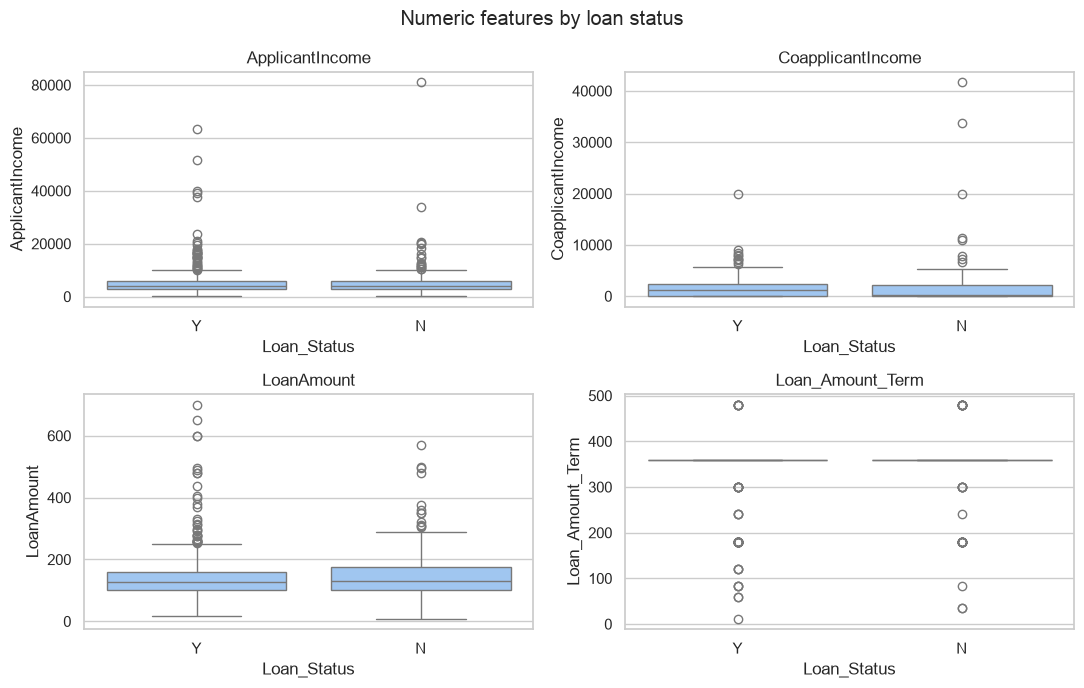

In [7]:
# Compare each numeric feature's distribution across approved (Y) and rejected (N) loans
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, column in zip(axes.ravel(), numeric_features):
    sns.boxplot(data=eda_data, x="Loan_Status", y=column, order=["Y", "N"], color="#93c5fd", ax=ax)
    ax.set_title(column)
plt.suptitle("Numeric features by loan status")
plt.tight_layout()
plt.show()


**Interpretation:** Income and loan amount look almost identical between Y and N (the boxes barely differ) so these features alone will probably don't separate approved from rejected applicants well. 

**Note:** Boxplot compares a numeric variable's distribution across categories, it doesn't have to be the target, just any categorical column you want to split by. Here it's against `Loan_Status` because the goal is checking whether each numeric feature helps separate approved from rejected applicants.

OJO: numérica (eje Y) + una categórica (eje X).

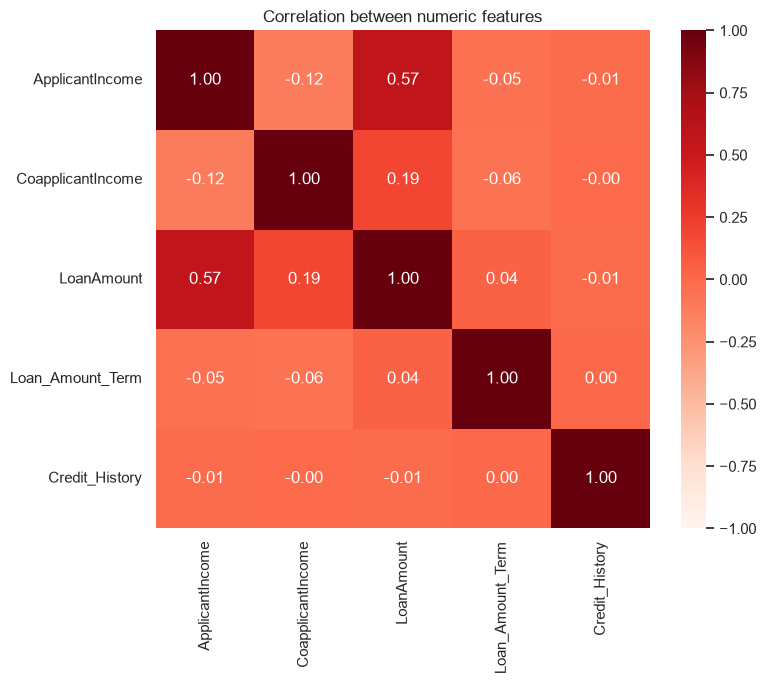

In [8]:
# Build a correlation matrix for the numeric features to check for redundancy before modelling
correlation_matrix = eda_data[numeric_features + ["Credit_History"]].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

**Interpretation:** No strong correlations here. The highest is `ApplicantIncome` vs. `LoanAmount` at 0.57, which makes sense: people who ask for a bigger loan usually earn more. Everything else is close to 0, including
`Credit_History`, which barely correlates with any numeric feature. That's actually useful for modelling:
low correlation means no redundant features to drop. It also shows Credit_History is independent from income and loan size, which is probably why it ends up being the strongest predictor of Loan_Status.

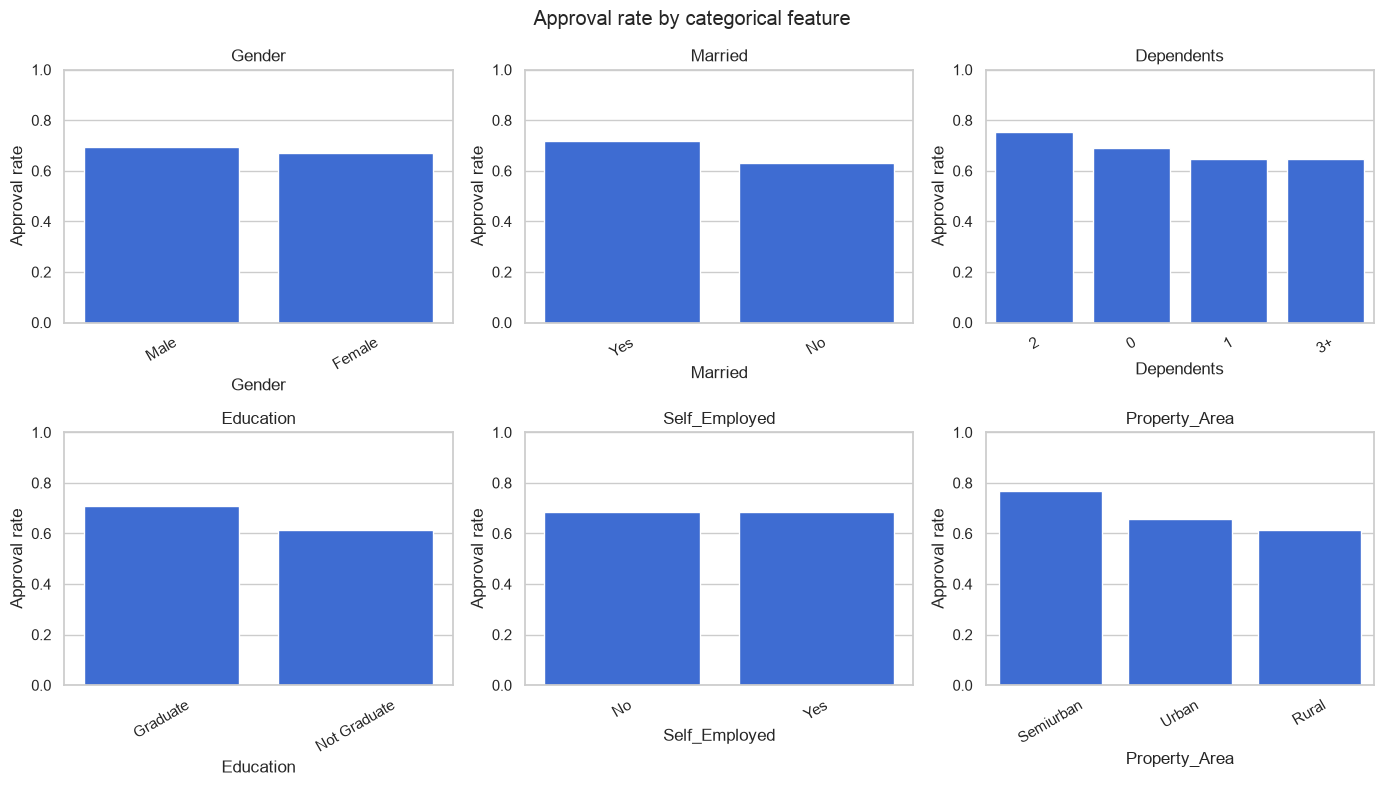

In [9]:
# Compute the loan-approval rate for each category of every categorical feature
categorical_features = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, column in zip(axes.ravel(), categorical_features):
    approval_rate = (
        eda_data.groupby(column)["Loan_Status"]
        .apply(lambda group: (group == "Y").mean())
        .sort_values(ascending=False)
    )
    sns.barplot(x=approval_rate.index, y=approval_rate.values, color="#2563eb", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Approval rate")
    ax.set_title(column)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Approval rate by categorical feature")
plt.tight_layout()
plt.show()

# approved loans (Loan_Status == 'Y') for each category.

**Interpretation:** Approval rates are fairly similar across `Gender`, `Married`, `Dependents`,
`Self_Employed` and `Property_Area` categories (mostly in the 65-75% range), so these features look like
weak individual predictors. `Education` shows a somewhat larger gap between graduates and non-graduates.
None of these gaps look as large as the one seen for `Credit_History` below.

,approval_rate
Credit_History,
0.0,0.079
1.0,0.796


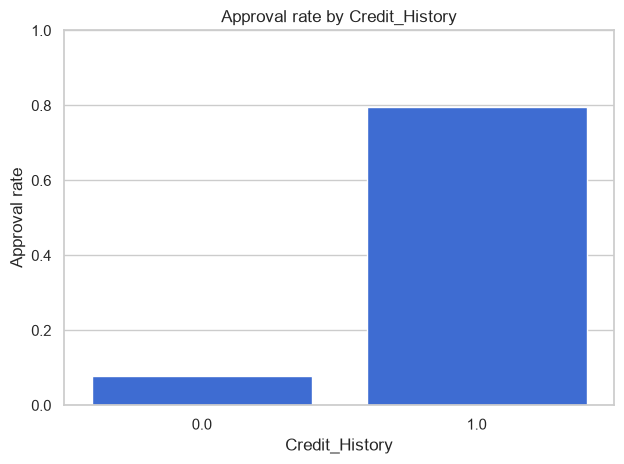

In [10]:
# Credit_History is stored as a number (0/1) but behaves like a category, so check it separately
credit_history_rate = (
    eda_data.groupby("Credit_History")["Loan_Status"]
    .apply(lambda group: (group == "Y").mean())
)
display(credit_history_rate.round(3).rename("approval_rate").to_frame())

sns.barplot(x=credit_history_rate.index.astype(str), y=credit_history_rate.values, color="#2563eb")
plt.ylim(0, 1)
plt.ylabel("Approval rate")
plt.xlabel("Credit_History")
plt.title("Approval rate by Credit_History")
plt.tight_layout()
plt.show()

**Interpretation:** `Credit_History` shows by far the biggest gap in approval rate: applicants with a
value of 1.0 are approved at a much higher rate than applicants with a value of 0.0. T

IMP:It also means missing `Credit_History` values (about 8% of rows) deserve extra care, since
imputing the wrong value could change a prediction.

# 4. Holdout split, Preprocessing Pipeline and Model Selection

## Holdout split 

In [11]:
#  80/20 stratified holdout split
model_data = data.dropna(subset=["Loan_Status"]).copy()
X = model_data.drop(columns="Loan_Status")
y = model_data["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training rows: {len(X_train):,} | Holdout rows: {len(X_test):,}")

Training rows: 491 | Holdout rows: 123


## Preprocessing

In [12]:
# numeric columns are median-imputed and scaled, categorical columns are imputed and one-hot encoded
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, selector(dtype_include=np.number)),
    ("categorical", categorical_pipeline, selector(dtype_exclude=np.number)),
])
print("Preprocessing pipeline defined.")


Preprocessing pipeline defined.


**Note on Decision Making :**
- **Median, not mean, for numeric imputation** : the earlier histograms showed `ApplicantIncome`,
  `CoapplicantIncome` and `LoanAmount` are all right-skewed with extreme outliers. A few very high earners
  would pull the mean far from a "typical" value, so filling gaps with the mean would insert an unrealistic
  number. The median is robust to that skew and stays close to what most applicants actually look like.
- **Most-frequent for categorical imputation** : categorical columns have no numeric average to compute,
  so the usual imputation choices are the mode (most-frequent category) or a constant placeholder like
  `"Missing"`.  Most-frequent was chosen because, without knowing the real value, replacing it by the most common one is the safest bet. A new `"Missing"` category risks creating a group with
  too few examples for the model to learn from.
- **StandardScaler** : Logistic Regression is sensitive to feature scale (it optimizes based on distances/
  gradients), so `ApplicantIncome` in the thousands would dominate over `Credit_History`'s 0/1 range purely
  because of units, not importance. Scaling puts every numeric feature on the same footing.

- **OneHotEncoder, not label/ordinal encoding** : columns like `Gender`, `Married`, `Property_Area` have no
  natural order (`Urban` isn't "more" than `Rural`). Label encoding assigns numbers (0, 1, 2...) that the
  model could wrongly read as ranked — e.g. `Urban=0, Rural=1, Semiurban=2` would imply `Semiurban > Urban`,
  which means nothing. One-hot avoids this by giving each category its own 0/1 column instead of a number,
  so no false order is introduced. Ordinal encoding is only appropriate when a real ranking exists, like
  `Low=0, Medium=1, High=2`.
 
- **`min_frequency=2`** : merges categories that appear only once into a single "infrequent" group instead of giving each its own column, keeping the encoding stable and avoiding near-empty columns.

Remember: All of this is fit only on the training split (inside the pipeline), so the median, mode and encoded
categories all come from training data alone. Never from data the model shouldn't have seen yet.

## Model Selection

In [13]:
baseline = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=160, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, estimator in {"Dummy baseline": baseline, **models}.items():
    candidate = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1, error_score="raise")
    rows.append({"Model": name, "CV macro F1": scores["test_score"].mean(), "CV std": scores["test_score"].std()})

comparison = pd.DataFrame(rows).sort_values("CV macro F1", ascending=False).reset_index(drop=True)
display(comparison.round(4))

# Fit the best non-dummy model on the full training partition, exactly as the original notebook does
eligible = comparison[comparison["Model"] != "Dummy baseline"]
best_name = eligible.iloc[0]["Model"]
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])])
best_pipeline.fit(X_train, y_train)
print(f"Selected model: {best_name}")

# naming the selected model (expected to match the original notebook's choice, Logistic Regression).

,Model,CV macro F1,CV std
0,Logistic Regression,0.7070,0.0766
1,Random Forest,0.6950,0.0736
2,Decision Tree,0.6661,0.0398
3,Dummy baseline,0.4070,0.0014


Selected model: Logistic Regression


**Note:** `DummyClassifier` is a baseline that always predicts the majority class a real model can't
beat it, it isn't learning anything useful. The hyperparameters here (`max_depth`, `n_estimators`, etc.)
are fixed, reasonable starting values chosen by hand, not tuned via grid search. The preprocessor is fitted
inside each `Pipeline`, so it always runs before the model on every fit/predict call. `StratifiedKFold`
splits training data into 5 folds, training and evaluating 5 times to get a more reliable score than a
single split, while keeping the Y/N ratio consistent across folds. Only after comparing all models is the
**winner refit once on the full training set** (`best_pipeline.fit`), that's the model used later on the
holdout and on `loan-test.csv`.

**Personal Note (typical values worth trying for these models):**


- **Logistic Regression:** `C` (regularization strength — try `0.01, 0.1, 1, 10, 100`; lower = more
  regularization), `max_iter` (`1000–2000` is usually enough to converge).
- **Decision Tree:** `max_depth` (`3–15`; controls overfitting — deeper trees memorize training data),
  `min_samples_leaf` (`1–10`; higher = smoother, less overfit boundaries).
- **Random Forest:** `n_estimators` (`100–500` trees; more is usually better but slower, with diminishing
  returns), `max_depth` and `min_samples_leaf` (same idea as the single tree), `max_features` (how many
  features each tree considers per split — `sqrt` is a common default for classification).

These ranges are common starting points for a grid or randomized search (`GridSearchCV`,
`RandomizedSearchCV`) — not values to guess by hand. This notebook fixes one reasonable value per
hyperparameter instead of searching, which is why the results here are a starting point, not a tuned model.

# 5. Holdout evaluation 

The model was already fitted in Section 4 (`best_pipeline.fit(X_train, y_train)`), but never checked
against ground truth. This section evaluates it on the untouched holdout set. 

This is the only place predictions are checked against known correct answers. This has to be done
before the model gets used on anything else, including `loan-test.csv` next.

In [14]:
# Generate predictions on the untouched holdout set with the already-fitted pipeline.
# No re-training happens here .predict() only uses what the pipeline already learned from X_train.
holdout_predictions = best_pipeline.predict(X_test)

# Accuracy and macro F1.
# Macro F1 averages the F1 score of each class equally, so it doesn't hide poor performance
# on the minority class ("N") the way plain accuracy can on an imbalanced target.
holdout_accuracy = accuracy_score(y_test, holdout_predictions)
holdout_macro_f1 = f1_score(y_test, holdout_predictions, average="macro")

print(f"Holdout accuracy: {holdout_accuracy:.4f}")
print(f"Holdout macro F1: {holdout_macro_f1:.4f}")

# classification_report breaks the same predictions down by class (precision, recall, F1, support),
# which is where an imbalance problem would actually show up.
print("\nClassification report:")
print(classification_report(y_test, holdout_predictions))


Holdout accuracy: 0.8618
Holdout macro F1: 0.8147

Classification report:
              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



**Implication:** the two classes behave very differently.
-For "N", precision is high (0.96) but recall is
low (0.58) so when the model predicts rejection it's almost always right, but it only catches about half of
the true rejections, letting the rest through as approvals. In other words, it defaults to approving rather than rejecting.

-For "Y", both precision (0.84) and recall (0.99) are high. The model is both usually right when it predicts approval, and it catches nearly every
true approval.

Overall, the model defaults toward "Y" whenever it's unsure, which is why "N" recall
suffers while "Y" stays strong on both fronts.

**Note — reading precision/recall together**

- **Both high** → the model is reliable for this class: it predicts it correctly and rarely misses it.
- **High precision, low recall** → cautious. When it predicts this class, it's usually right — but it
  misses many true cases of it, letting them slip into the other class (this is "N" here: 0.96 precision,
  0.58 recall).
- **Low precision, high recall** → trigger-happy. Predicts this class too often, catching most true cases but
  also mislabeling many others as it.
- **Both low** → the model doesn't handle this class well at all — it neither predicts it correctly often,
  nor catches most of the true cases.

There's usually a trade-off between the two: pushing a model to catch more true cases (higher recall) tends
to make it label more things as that class overall, which lowers precision, and vice versa.

**Note — reading the classification report**

Each row is one class ("Y" = approved, "N" = rejected). 

The columns:

- **precision** : what fraction was actually correct.
  `N: 0.96` → when the model says "N", it's right 96% of the time.
- **recall** : of everything that truly belongs to this class, what fraction the model caught.
  `N: 0.58` → of all true rejections, the model only caught 58%; it missed the rest.
- **f1-score** : the balance of precision and recall for that class, in one number.
- **support** : how many true examples of that class were in the holdout (38 "N", 85 "Y" — imbalanced).
- **macro avg** : precision/recall/F1 averaged equally across both classes. It's the
primary metric because both classes count the same. 

- **weighted avg** : the same average, but weighted by class size — closer to plain accuracy, and easily
  hides a weak minority class, which is why it's not the primary metric here.

**Example:** say "N" scores 0.50 F1 and "Y" scores 0.90 F1.
    - **macro avg** = (0.50 + 0.90) / 2 = **0.70** — the weak "N" score pulls the average down, clearly visible.
    - **weighted avg** (85 "Y", 38 "N") = (38×0.50 + 85×0.90) / 123 ≈ **0.78** — closer to the "Y" score alone,
      since "Y" has more rows and dominates the average, making the weak "N" performance less visible.
      

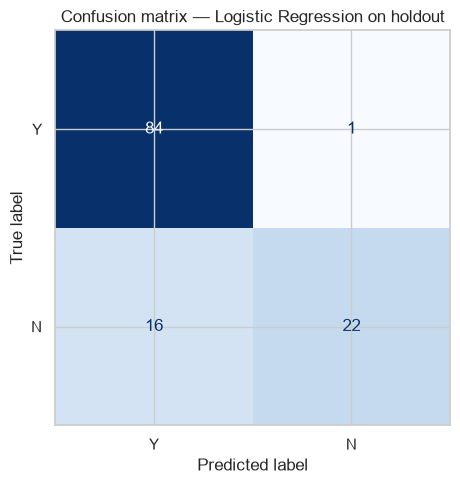

In [15]:
# Visualise the same predictions as a confusion matrix: rows = true label, columns = predicted label.
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, holdout_predictions, labels=["Y", "N"], cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"Confusion matrix — {best_name} on holdout")
plt.tight_layout()
plt.show()

**Note — reading the confusion matrix**

Rows = true label, columns = predicted label. Reading this matrix:

- **Top-left (84):** true "Y", predicted "Y" — correct approvals.
- **Bottom-right (22):** true "N", predicted "N" — correct rejections.
- **Top-right (1):** true "Y", predicted "N" — a good applicant wrongly rejected (false negative).
- **Bottom-left (16):** true "N", predicted "Y" — a bad applicant wrongly approved (false positive).

**Interpretation for this section:** Holdout accuracy (0.86) and macro F1 (0.81) are higher than the
cross-validated macro F1 from Section 4 (0.707 ± 0.077), so no sign
of overfitting, just a holdout split the model did well on. 

The classification report and confusion matrix
explain why: the model rarely misses a true approval, but misses over 40% of true rejections, defaulting to
approval when unsure — of 38 true rejections, only 22 were caught, the other 16 were wrongly approved.

# 6. Score the unlabeled `loan-test.csv` scoring set

Now that Section 5 has confirmed the model performs reasonably on known data, it can be used on new,
unlabeled applicants. `loan-test.csv` has no `Loan_Status` column, so this section only generates and
saves predictions (there is nothing here to score against).

In [16]:
# Load the unlabeled scoring file the same way the training file was loaded
# Import the unlabeled scoring file
raw_test = pd.read_csv('loan-test.csv')

print(f"Loaded loan-test.csv: {raw_test.shape[0]:,} rows x {raw_test.shape[1]} columns")
raw_test

Loaded loan-test.csv: 367 rows x 12 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [17]:
# Keep the Loan_ID values before cleaning, since prepare_frame() drops that column!!
scoring_ids = raw_test["Loan_ID"].copy()

# Clean the scoring file with the exact same function used on the training data
scoring_data = prepare_frame(raw_test)

# Confirm the scoring file has the same feature columns the pipeline was trained on
expected_columns = set(X_train.columns)
actual_columns = set(scoring_data.columns)
print("Columns match training features:", expected_columns == actual_columns)


Columns match training features: True


In [18]:
# Generate predictions for every row in the scoring file with the fitted best pipeline
scoring_predictions = best_pipeline.predict(scoring_data)

# Build a submission-style table pairing each Loan_ID with its predicted Loan_Status
submission = pd.DataFrame({
    "Loan_ID": scoring_ids,
    "Predicted_Loan_Status": scoring_predictions,
})
display(submission.head())

# Save the predictions to a CSV file in the same folder as the notebook
submission.to_csv("loan-test-predictions.csv", index=False)
print(f"Saved {len(submission):,} predictions to loan-test-predictions.csv")
# Expected output: a preview of the first five predictions, then a confirmation line naming the saved file.

,Loan_ID,Predicted_Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


Saved 367 predictions to loan-test-predictions.csv


**Note — scoring workflow**

This only runs after the model is trained AND evaluated on the holdout, never before:

Train model on `X_train` / `y_train`
→ Evaluate on holdout `X_test` / `y_test` (Section 5 — has ground truth, so real metrics are possible)
→ Load `loan-test.csv` (a separate file — no `Loan_Status`, no ground truth)
→ Clean it the same way as training data
→ Predict with the already-fitted pipeline (no re-training here)
→ Save predictions

**Two different files, two different jobs:**
- `X_test` / `y_test` → cut from `loan-train.csv`, has the true answer → used to check if the model works.
- `loan-test.csv` → a separate file, never had a true answer → used only to generate new predictions.

# 7.  Error Analysis and Subgroup performance
Section 5 showed the model misses many true rejections. This section looks at *which* holdout applicants
get misclassified and *whether* accuracy holds steady across subgroups.

In [19]:
# Line up holdout predictions with the true labels and original features, row by row.
error_review = X_test.copy()
error_review["Actual_Loan_Status"] = y_test.values
error_review["Predicted_Loan_Status"] = holdout_predictions
error_review["Correct"] = error_review["Actual_Loan_Status"] == error_review["Predicted_Loan_Status"]

misclassified = error_review[~error_review["Correct"]]
print(f"Holdout rows: {len(error_review)} | Misclassified: {len(misclassified)} "
      f"({len(misclassified) / len(error_review):.1%})")
display(misclassified.head(10))
# Expected misclassified : 16+1=17

Holdout rows: 123 | Misclassified: 17 (13.8%)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Actual_Loan_Status,Predicted_Loan_Status,Correct
191,Male,No,0,Graduate,No,12000,0.0,164.0,360.0,1.0,Semiurban,N,Y,False
326,Male,No,0,Graduate,No,4917,0.0,130.0,360.0,0.0,Rural,Y,N,False
268,Female,No,0,Graduate,NaN,3418,0.0,135.0,360.0,1.0,Rural,N,Y,False
479,Male,Yes,2,Graduate,No,2947,1603.0,NaN,360.0,1.0,Urban,N,Y,False
216,Male,Yes,0,Graduate,No,150,1800.0,135.0,360.0,1.0,Rural,N,Y,False
487,Male,Yes,1,Graduate,No,18333,0.0,500.0,360.0,1.0,Urban,N,Y,False
510,Male,No,0,Not Graduate,No,3598,1287.0,100.0,360.0,1.0,Rural,N,Y,False
153,Male,Yes,2,Not Graduate,No,2281,0.0,113.0,360.0,1.0,Rural,N,Y,False
34,Male,No,3+,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N,Y,False
314,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N,Y,False


In [20]:
# Split mistakes by type: false positives (approved but should be rejected) vs.
# false negatives (rejected but should be approved) — these have different real-world costs.
false_positives = misclassified[
    (misclassified["Predicted_Loan_Status"] == "Y") & (misclassified["Actual_Loan_Status"] == "N")
]
false_negatives = misclassified[
    (misclassified["Predicted_Loan_Status"] == "N") & (misclassified["Actual_Loan_Status"] == "Y")
]
print(f"False positives (approved but should be rejected): {len(false_positives)}")
print(f"False negatives (rejected but should be approved): {len(false_negatives)}")

# Compare their average profile on key numeric features against the holdout overall.
profile_columns = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Credit_History"]
error_profile = pd.DataFrame({
    "False positives (mean)": false_positives[profile_columns].mean(),
    "False negatives (mean)": false_negatives[profile_columns].mean(),
    "Holdout overall (mean)": X_test[profile_columns].mean(),
})
display(error_profile.round(2))

False positives (approved but should be rejected): 16
False negatives (rejected but should be approved): 1


,False positives (mean),False negatives (mean),Holdout overall (mean)
ApplicantIncome,5688.19,4917.0,4898.33
CoapplicantIncome,1146.94,0.0,1827.66
LoanAmount,182.67,130.0,142.92
Credit_History,1.00,0.0,0.81


**Note — reading the table**

Each row is a numeric feature; each column is a group's average. Compare each group to "Holdout overall". A big
gap suggests that feature may relate to the error, a small gap suggests it doesn't.

- **ApplicantIncome:** FP 5688 vs. overall 4898 -> a bit higher, not a big gap.
- **CoapplicantIncome:** FP 1147 vs. overall 1828 -> lower, but based on only 16 cases, not a strong signal.
- **LoanAmount:** FP 183 vs. overall 143 -> slightly higher, small gap, not a strong signal.
- **Credit_History:** FP 1.00 vs. overall 0.81 -> all 16 false positives have `Credit_History = 1`. This is
  the one clear, consistent pattern: the model approves almost automatically whenever credit history looks
  good, even when that turns out to be wrong.

False negatives (only 1 case) aren't included here . A single row isn't a pattern, just one applicant.

In [21]:
# Check whether errors cluster in specific subgroups, one categorical feature at a time.
# A p_value is added so differences aren't judged by eye alone. A low p-value (< 0.05) means 
#the gap is unlikely to be sample noise but real.-> esto es un hallazgo real, no una casualidad.

from scipy.stats import binomtest

overall_error_rate = 1 - error_review["Correct"].mean()

def subgroup_scores(frame, group_column):
    summary = (
        frame.groupby(group_column, dropna=False)
        .agg(rows=("Correct", "size"), accuracy=("Correct", "mean"))
        .round(3)
    )
    summary["errors"] = summary["rows"] - (summary["rows"] * summary["accuracy"]).round().astype(int)
    summary["p_value"] = [
        binomtest(errors, rows, overall_error_rate, alternative="two-sided").pvalue
        for errors, rows in zip(summary["errors"], summary["rows"])
    ]
    return summary.round(3)

for column in ["Credit_History", "Gender", "Married", "Property_Area", "Education"]:
    print(f"--- Accuracy by {column} ---")
    display(subgroup_scores(error_review, column))


--- Accuracy by Credit_History ---


,rows,accuracy,errors,p_value
Credit_History,,,,
0.0,22,0.955,1,0.350
1.0,94,0.830,16,0.369
NaN,7,1.000,0,0.604


--- Accuracy by Gender ---


,rows,accuracy,errors,p_value
Gender,,,,
Female,25,0.840,4,0.770
Male,96,0.875,12,0.882
NaN,2,0.500,1,0.257


--- Accuracy by Married ---


,rows,accuracy,errors,p_value
Married,,,,
No,44,0.818,8,0.382
Yes,79,0.886,9,0.627


--- Accuracy by Property_Area ---


,rows,accuracy,errors,p_value
Property_Area,,,,
Rural,34,0.676,11,0.005
Semiurban,49,0.959,2,0.059
Urban,40,0.900,4,0.648


--- Accuracy by Education ---


,rows,accuracy,errors,p_value
Education,,,,
Graduate,100,0.86,14,0.885
Not Graduate,23,0.87,3,1.000


**Why a p-value:** in the code `Correct` marks whether each holdout prediction matched the true label (True/False
per row). `overall_error_rate = 1 - error_review["Correct"].mean()` turns that into a single number:
the model's error rate across the whole holdout (14%) — the baseline every subgroup is compared to.

With few rows per subgroup, a bad-looking accuracy has two possible explanations: luck (this
particular sample happened to get more errors) or a real pattern (the model genuinely performs
worse for that group). The p-value estimates how likely "luck" is:

- **p-value < 0.05:** "luck" is unlikely → the gap is probably a real pattern.
- **p-value > 0.05:** "luck" can't be ruled out → the gap is not confirmed either way.

**Interpretation:** Only `Property_Area = Rural` shows a statistically significant gap (p = 0.005): the model is more likely to get it wrong when predicting loan approval for rural applicants than for any other group (67.6% accuracy vs. 86% overall). No other subgroup shows a confirmed gap.

# 8. Summary 

**Key findings:**

- `Credit_History` is the strongest predictor of loan approval. Applicants with a qualifying
  credit history are approved at a much higher rate than those without, while income and loan amount show
  little difference between approved and rejected applicants on their own.
- Logistic Regression was selected via cross-validated macro F1 and reached 0.86 accuracy / 0.81 macro F1
  on the holdout, close to its cross-validation score, so the model generalises well rather than
  overfitting.
- The model is much better at approving true approvals (0.99 recall) than at catching true rejections
  (0.58 recall) , it defaults toward approving when uncertain, and most holdout errors are applicants who
  should have been rejected but weren't.
- Predictions on the unlabeled `loan-test.csv` set were generated and saved to
  `loan-test-predictions.csv`, with a predicted approval rate close to the training approval rate.

**Limitations:** hyperparameters were fixed by hand, not tuned; the dataset is small (614 training rows);
and accuracy dips for some subgroups (see Section 7), which is worth addressing before any real-world use.